In [2]:
import pandas as pd

matches = pd.read_csv("data/matches.csv")
deliveries = pd.read_csv("data/deliveries.csv")

matches.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [6]:
top_batsmen = deliveries.groupby("batsman")["batsman_runs"].sum().sort_values(ascending=False).head(10)

top_batsmen

batsman
SK Raina          4548
V Kohli           4423
RG Sharma         4207
G Gambhir         4132
DA Warner         4014
RV Uthappa        3778
CH Gayle          3651
S Dhawan          3561
MS Dhoni          3560
AB de Villiers    3486
Name: batsman_runs, dtype: int64

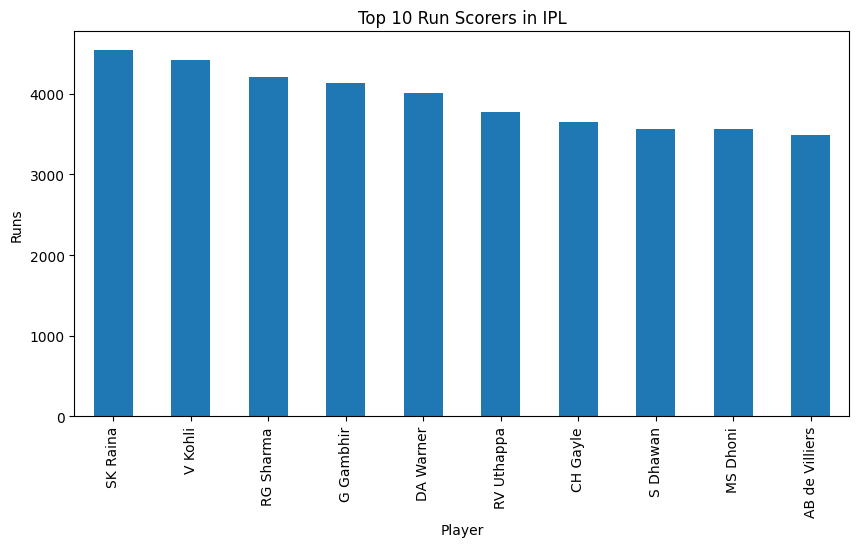

In [8]:
import matplotlib.pyplot as plt

top_batsmen.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Run Scorers in IPL")
plt.xlabel("Player")
plt.ylabel("Runs")

plt.show()

Top players dominate total run scoring, showing consistent performance across multiple IPL seasons.

In [11]:
top_bowlers = deliveries[deliveries["dismissal_kind"].notna()]

top_bowlers = top_bowlers.groupby("bowler")["dismissal_kind"].count().sort_values(ascending=False).head(10)

top_bowlers

bowler
SL Malinga         170
A Mishra           142
DJ Bravo           137
Harbhajan Singh    136
PP Chawla          133
R Vinay Kumar      125
A Nehra            121
Z Khan             119
B Kumar            117
R Ashwin           110
Name: dismissal_kind, dtype: int64

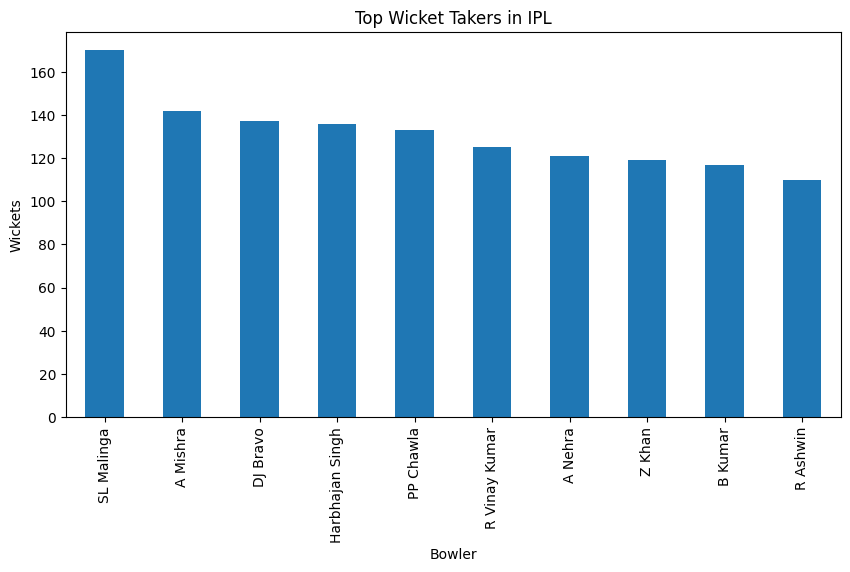

In [12]:
top_bowlers.plot(kind="bar", figsize=(10,5))

plt.title("Top Wicket Takers in IPL")
plt.xlabel("Bowler")
plt.ylabel("Wickets")

plt.show()

Winning the toss gives a slight advantage, but it does not guarantee match victory.

In [13]:
toss_win_match_win = matches[matches["toss_winner"] == matches["winner"]]

percentage = (len(toss_win_match_win) / len(matches)) * 100

percentage

51.98412698412699

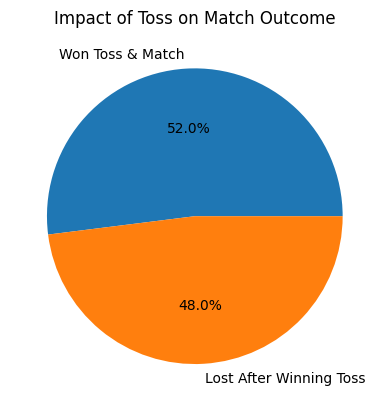

In [14]:
labels = ["Won Toss & Match", "Lost After Winning Toss"]
sizes = [len(toss_win_match_win), len(matches) - len(toss_win_match_win)]

import matplotlib.pyplot as plt

plt.pie(sizes, labels=labels, autopct="%1.1f%%")
plt.title("Impact of Toss on Match Outcome")

plt.show()

Certain teams dominate the IPL with more wins, showing long-term consistency and strength.

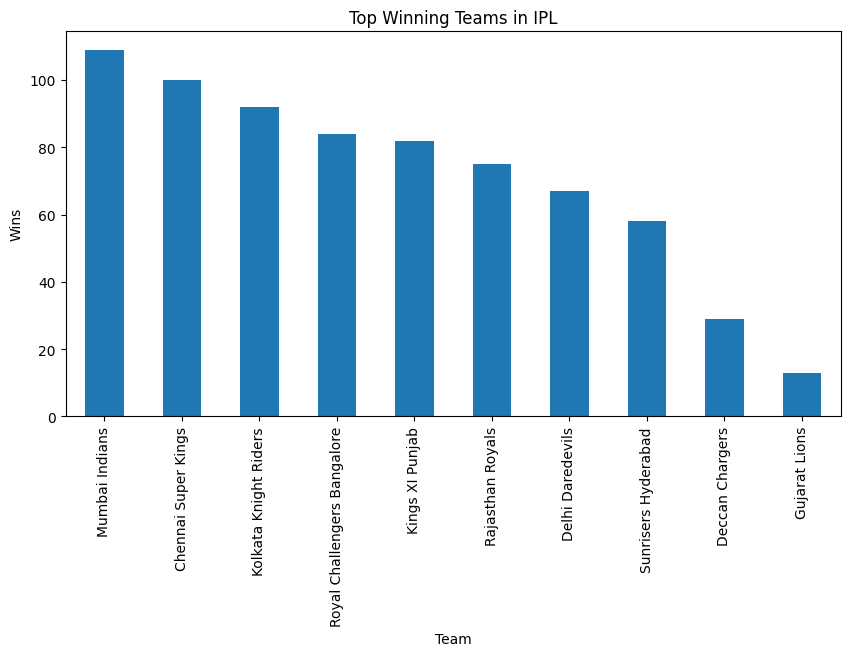

In [15]:
team_wins = matches["winner"].value_counts().head(10)

team_wins.plot(kind="bar", figsize=(10,5))

plt.title("Top Winning Teams in IPL")
plt.xlabel("Team")
plt.ylabel("Wins")

plt.show()

A few teams dominate IPL wins, showing consistent performance across seasons.

In [16]:
# Powerplay (overs 1–6)
powerplay = deliveries[deliveries["over"] <= 6]

# Death overs (overs 16–20)
death_overs = deliveries[deliveries["over"] >= 16]

# Total runs
powerplay_runs = powerplay["batsman_runs"].sum()
death_runs = death_overs["batsman_runs"].sum()

powerplay_runs, death_runs

(np.int64(53643), np.int64(49600))

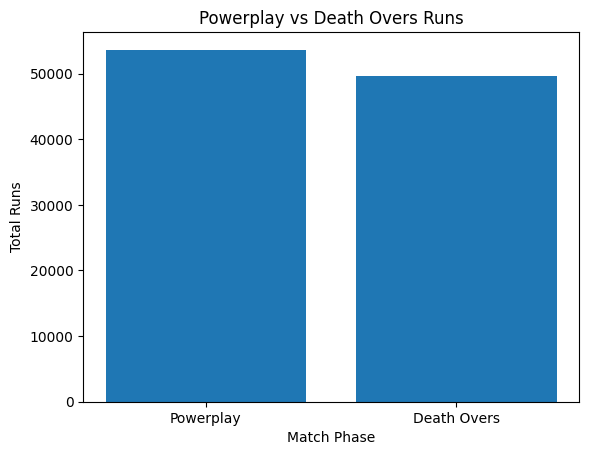

In [17]:
labels = ["Powerplay", "Death Overs"]
runs = [powerplay_runs, death_runs]

import matplotlib.pyplot as plt

plt.bar(labels, runs)

plt.title("Powerplay vs Death Overs Runs")
plt.xlabel("Match Phase")
plt.ylabel("Total Runs")

plt.show()

Death overs generate significantly more runs compared to powerplay, showing aggressive batting strategies in the final overs.